YOLOv5-nano ONNX Inference

[1] Загрузка модели: models/yolov5nu.onnx
Вход: images -> [1, 3, 416, 416]
Выходов: 1
  [0] output0: [1, 84, 3549]

[2] Предобработка: data/VOC2012/JPEGImages/2007_005989.jpg
Входной тензор: (1, 3, 416, 416)

[3] Инференс...

[4] Декодирование...
После транспонирования: (3549, 84)
  Boxes range (raw): [2.76, 413.16]
  Class scores max: 0.8257
  Декодировано: (3549, 85), objness range: [0.0000, 0.8257]

[5] Постобработка...
После фильтрации (conf>0.5): 6 кандидатов
Найдено объектов: 1

Отрисовка 1 объектов:
  1. motorcycle: [138, 141, 407, 273], score=0.682


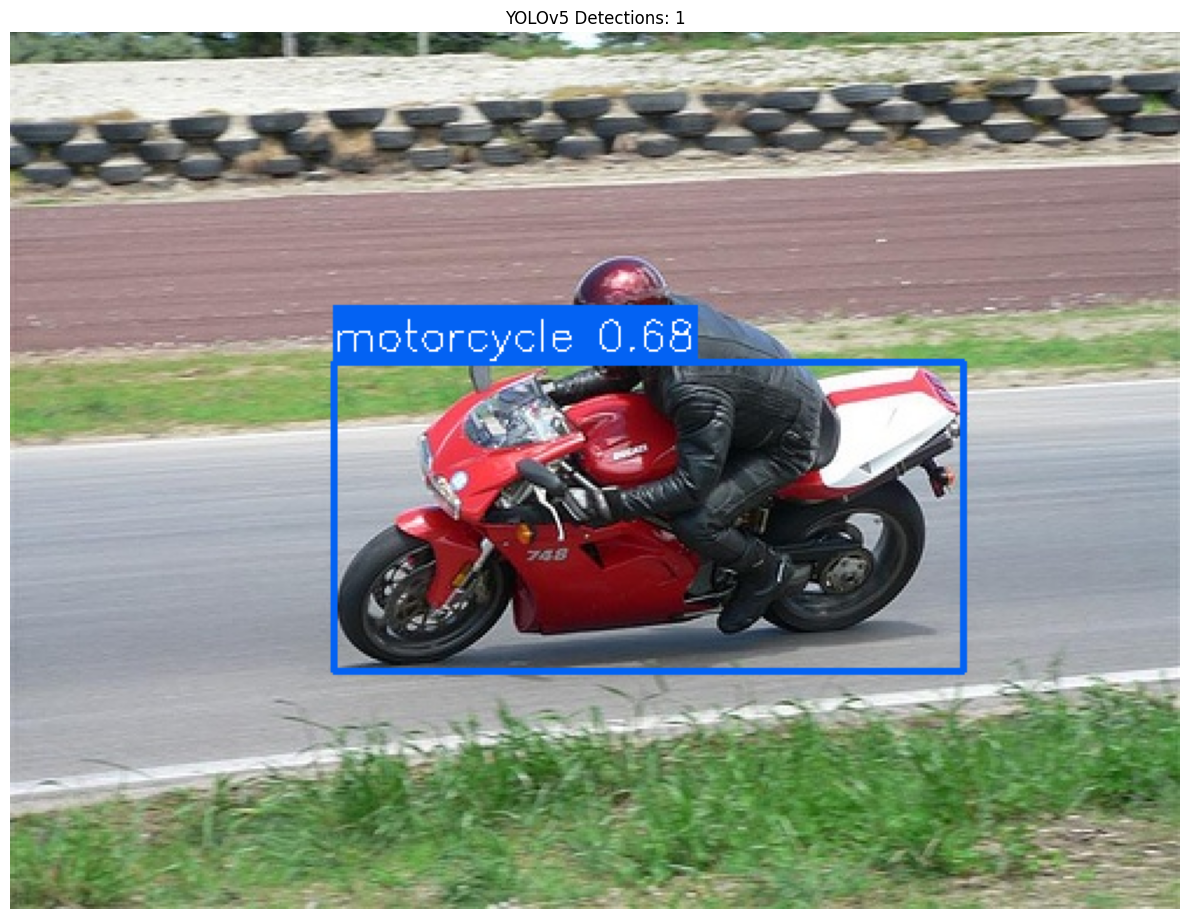

In [2]:
# ============================================
# YOLOv5-nano ONNX Inference (Для сравнения с YOLOX-Tiny)
# ============================================

import numpy as np
import cv2
import onnxruntime as ort
from matplotlib import pyplot as plt

# Параметры модели (YOLOv5-nano)
INPUT_SIZE = 416
NUM_CLASSES = 80  # COCO dataset
STRIDES = [8, 16, 32]

# Якоря YOLOv5 (COCO) для каждого уровня FPN
ANCHORS = [
    [[10, 13], [16, 30], [33, 23]],      # P3/8 (мелкие объекты)
    [[30, 61], [62, 45], [59, 119]],     # P4/16 (средние)
    [[116, 90], [156, 198], [373, 326]]  # P5/32 (крупные)
]

CLASS_NAMES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup',
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink',
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]


# ============================================
# Предобработка (идентична YOLOX для честного сравнения)
# ============================================

def preprocess(image_path, input_size=INPUT_SIZE):
    """
    Загрузка и предобработка изображения для YOLOv5
    Важно: используем ТУ ЖЕ предобработку что и YOLOX (letterbox 114, /255)
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Не удалось загрузить {image_path}")
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_shape = img.shape[:2]  # (H, W)
    
    h, w = original_shape
    scale = min(input_size / h, input_size / w)
    new_h, new_w = int(h * scale), int(w * scale)
    
    # Resize
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    
    # Pad to input_size (серый цвет 114 как в YOLOX)
    padded = np.full((input_size, input_size, 3), 114, dtype=np.uint8)
    padded[:new_h, :new_w] = resized
    
    # Normalize [0, 1] (YOLOv5 использует /255 в отличие от ImageNet norm у NanoDet)
    padded = padded.astype(np.float32) / 255.0
    padded = padded.transpose(2, 0, 1)  # CHW
    padded = np.expand_dims(padded, 0)  # BCHW
    
    return padded, img, (scale, new_h, new_w), original_shape


# ============================================
# Декодирование выхода YOLOv5 (главное отличие от YOLOX!)
# ============================================

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def make_grid(nx, ny):
    """Создает сетку координат для grid"""
    xv, yv = np.meshgrid(np.arange(nx), np.arange(ny))
    return np.stack((xv, yv), axis=2).reshape((1, 1, ny, nx, 2)).astype(np.float32)


def decode_yolov5_output(outputs, input_size=INPUT_SIZE, strides=STRIDES, anchors=ANCHORS):
    """
    Декодирование сырого выхода YOLOv5.
    
    YOLOv5 выдает 3 тензора (P3, P4, P5) формы:
    - [1, 3, 52, 52, 85] для stride 8
    - [1, 3, 26, 26, 85] для stride 16  
    - [1, 3, 13, 13, 85] для stride 32
    
    Где 85 = [x, y, w, h, obj, 80 classes]
    x,y относительно ячейки (0-1), w,h относительно anchors (логарифм)
    """
    all_predictions = []
    
    print(f"Количество выходов модели: {len(outputs)}")
    
    for i, (stride, anchor, pred) in enumerate(zip(strides, anchors, outputs)):
        batch_size, num_anchors, ny, nx, features = pred.shape
        
        print(f"  Уровень P{i+3}: {pred.shape}, stride={stride}")
        
        # Применяем sigmoid к x, y, obj, cls (но не к w, h!)
        pred = sigmoid(pred)
        
        # Создаем grid для этого уровня
        grid = make_grid(nx, ny)  # [1, 1, ny, nx, 2]
        
        # Декодируем xy: (grid + sigmoid(pred_xy)) * stride
        pred[..., 0:2] = (pred[..., 0:2] * 2. - 0.5 + grid) * stride  # xy
        
        # Декодируем wh: anchor * exp(pred_wh) * 2
        anchor_grid = np.array(anchor).reshape((1, num_anchors, 1, 1, 2))
        pred[..., 2:4] = (pred[..., 2:4] * 2) ** 2 * anchor_grid  # wh
        
        # Решейпим в [batch, num_anchors*ny*nx, 85]
        pred = pred.reshape((batch_size, -1, features))
        all_predictions.append(pred)
    
    # Конкатенируем все уровни
    predictions = np.concatenate(all_predictions, axis=1)[0]  # [10647, 85] для 416x416
    
    print(f"  Итого anchor: {predictions.shape[0]}")
    
    # Преобразуем xywh -> xyxy
    boxes = predictions[:, :4]
    xyxy = np.copy(boxes)
    xyxy[:, 0] = boxes[:, 0] - boxes[:, 2] / 2  # x1
    xyxy[:, 1] = boxes[:, 1] - boxes[:, 3] / 2  # y1
    xyxy[:, 2] = boxes[:, 0] + boxes[:, 2] / 2  # x2
    xyxy[:, 3] = boxes[:, 1] + boxes[:, 3] / 2  # y2
    
    predictions[:, :4] = xyxy
    
    return predictions


def decode_single_output(raw_output, input_size=INPUT_SIZE):
    """
    Декодирование для YOLOv5nu ONNX с выходом [1, 84, 3549]
    Формат: 84 = 4 (xywh) + 80 (class scores), objectness отсутствует (берется как max class)
    """
    predictions = raw_output[0]  # [84, 3549]
    
    # ТРАНСПОНИРУЕМ чтобы получить [3549, 84]
    predictions = predictions.T  # [3549, 84]
    print(f"После транспонирования: {predictions.shape}")
    
    # Разделяем: xywh + class scores
    boxes = predictions[:, :4]           # [3549, 4] - xywh (center format)
    class_scores = predictions[:, 4:]    # [3549, 80] - только классы, objness отдельно отсутствует!
    
    print(f"  Boxes range (raw): [{boxes.min():.2f}, {boxes.max():.2f}]")
    print(f"  Class scores max: {class_scores.max():.4f}")
    
    # Objectness отсутствует в этом формате, используем max class probability
    objness = np.max(class_scores, axis=1, keepdims=True)  # [3549, 1]
    
    # Масштабируем боксы если они нормализованы (0-1)
    if boxes.max() <= 1.0:
        boxes = boxes * input_size
    
    # Преобразуем xywh -> xyxy для NMS
    xyxy = np.copy(boxes)
    xyxy[:, 0] = boxes[:, 0] - boxes[:, 2] / 2  # x1 = cx - w/2
    xyxy[:, 1] = boxes[:, 1] - boxes[:, 3] / 2  # y1 = cy - h/2
    xyxy[:, 2] = boxes[:, 0] + boxes[:, 2] / 2  # x2 = cx + w/2
    xyxy[:, 3] = boxes[:, 1] + boxes[:, 3] / 2  # y2 = cy + h/2
    
    # Собираем в формат совместимый с postprocess: [xyxy, objness, class_scores]
    # Итоговая форма: [3549, 85] где 85 = 4 (xyxy) + 1 (objness) + 80 (classes)
    decoded = np.concatenate([xyxy, objness, class_scores], axis=1)
    
    print(f"  Декодировано: {decoded.shape}, objness range: [{objness.min():.4f}, {objness.max():.4f}]")
    
    return decoded


# ============================================
# Постобработка (идентична YOLOX)
# ============================================

def postprocess(predictions, scale_info, conf_thre=0.3, nms_thre=0.45):
    """
    Фильтрация по confidence, NMS и масштабирование к оригинальному изображению
    """
    boxes = predictions[:, :4]
    objness = predictions[:, 4]
    class_scores = predictions[:, 5:]
    
    # Общий score = objectness * class_probability
    scores = objness[:, np.newaxis] * class_scores
    max_scores = np.max(scores, axis=1)
    class_ids = np.argmax(scores, axis=1)
    
    # Фильтр по confidence
    valid_mask = max_scores > conf_thre
    boxes = boxes[valid_mask]
    scores = max_scores[valid_mask]
    class_ids = class_ids[valid_mask]
    
    print(f"После фильтрации (conf>{conf_thre}): {len(boxes)} кандидатов")
    
    if len(boxes) == 0:
        return np.array([])
    
    # NMS
    indices = cv2.dnn.NMSBoxes(
        boxes.tolist(),
        scores.tolist(),
        conf_thre,
        nms_thre
    )
    
    if len(indices) == 0:
        return np.array([])
    
    indices = indices.flatten() if hasattr(indices, 'flatten') else indices
    
    # Собираем результаты
    dets = []
    for idx in indices:
        dets.append([*boxes[idx], scores[idx], class_ids[idx]])
    dets = np.array(dets)
    
    # Масштабируем к оригинальному изображению
    scale, new_h, new_w = scale_info
    dets[:, [0, 2]] = dets[:, [0, 2]] / scale
    dets[:, [1, 3]] = dets[:, [1, 3]] / scale
    
    return dets


# ============================================
# Визуализация (идентична YOLOX)
# ============================================

def visualize(image, detections, class_names, save_path=None):
    """Отрисовка боксов (код без изменений)"""
    if len(detections) == 0:
        print("Нет детекций для отображения")
        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.title("No detections")
        plt.show()
        return image
    
    img_vis = image.copy()
    h, w = img_vis.shape[:2]
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(class_names), 3), dtype=np.uint8)
    
    print(f"\nОтрисовка {len(detections)} объектов:")
    
    for i, det in enumerate(detections):
        x1, y1, x2, y2, score, cls_id = det
        cls_id = int(cls_id)
        
        x1 = int(np.clip(x1, 0, w - 1))
        y1 = int(np.clip(y1, 0, h - 1))
        x2 = int(np.clip(x2, 0, w - 1))
        y2 = int(np.clip(y2, 0, h - 1))
        
        if x2 <= x1 or y2 <= y1:
            continue
        
        color = (int(colors[cls_id][0]), int(colors[cls_id][1]), int(colors[cls_id][2]))
        label = f"{class_names[cls_id]} {score:.2f}"
        
        cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, 2)
        
        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img_vis, (x1, y1 - text_h - 10), (x1 + text_w, y1), color, -1)
        cv2.putText(img_vis, label, (x1, y1 - 5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        
        print(f"  {i+1}. {class_names[cls_id]}: [{x1}, {y1}, {x2}, {y2}], score={score:.3f}")
    
    plt.figure(figsize=(12, 10))
    plt.imshow(img_vis)
    plt.axis('off')
    plt.title(f"YOLOv5 Detections: {len(detections)}")
    plt.tight_layout()
    
    if save_path:
        plt.imsave(save_path, img_vis)
    
    plt.show()
    return img_vis


# ============================================
# Главная функция
# ============================================

def run_inference(onnx_path, image_path, conf_thre=0.3, nms_thre=0.45):
    """
    Полный pipeline инференса YOLOv5-nano
    """
    print("=" * 60)
    print("YOLOv5-nano ONNX Inference")
    print("=" * 60)
    
    # 1. Загрузка модели
    print(f"\n[1] Загрузка модели: {onnx_path}")
    session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    
    input_name = session.get_inputs()[0].name
    print(f"Вход: {input_name} -> {session.get_inputs()[0].shape}")
    
    outputs_info = session.get_outputs()
    print(f"Выходов: {len(outputs_info)}")
    for i, out in enumerate(outputs_info):
        print(f"  [{i}] {out.name}: {out.shape}")
    
    # 2. Предобработка
    print(f"\n[2] Предобработка: {image_path}")
    input_tensor, original_img, scale_info, orig_shape = preprocess(image_path)
    print(f"Входной тензор: {input_tensor.shape}")
    
    # 3. Инференс
    print(f"\n[3] Инференс...")
    outputs = session.run(None, {input_name: input_tensor})
    
    # 4. Декодирование (автоопределение формата)
    print(f"\n[4] Декодирование...")
    
    if len(outputs) == 3:
        # 3 выхода (P3, P4, P5) - стандартный экспорт
        predictions = decode_yolov5_output(outputs, input_size=INPUT_SIZE)
    elif len(outputs) == 1:
        # 1 выход (уже объединенный)
        predictions = decode_single_output(outputs[0], input_size=INPUT_SIZE)
    else:
        raise ValueError(f"Неожиданное количество выходов: {len(outputs)}")
    
    # 5. Постобработка
    print(f"\n[5] Постобработка...")
    detections = postprocess(predictions, scale_info, conf_thre, nms_thre)
    print(f"Найдено объектов: {len(detections)}")
    
    # 6. Визуализация
    if len(detections) > 0:
        visualize(original_img, detections, CLASS_NAMES)
    
    return detections


# ============================================
# Запуск
# ============================================

if __name__ == "__main__":
    # Укажите путь к YOLOv5 ONNX (416x416)
    ONNX_MODEL_PATH = "models/yolov5nu.onnx"
    IMAGE_PATH = "data/VOC2012/JPEGImages/2007_005989.jpg"
    
    detections = run_inference(
        ONNX_MODEL_PATH, 
        IMAGE_PATH, 
        conf_thre=0.5,  # Попробуй 0.25 для больше детекций
        nms_thre=0.45
    )

In [ ]:
if __name__ == "__main__":
    # Укажите путь к YOLOv5 ONNX (416x416)
    ONNX_MODEL_PATH = "models/yolov5nu.onnx"
    IMAGE_PATH = "data/VOC2012/JPEGImages/2007_005989.jpg"
    
    detections = run_inference(
        ONNX_MODEL_PATH, 
        IMAGE_PATH, 
        conf_thre=0.5,  # Попробуй 0.25 для больше детекций
        nms_thre=0.45
    )

In [3]:
import os
import glob
from pathlib import Path

# ... (предыдущие импорты и функции run_inference, CLASS_NAMES и т.д.)

def process_folder(
    model_path: str,
    folder_path: str,
    conf_thre: float = 0.5,
    nms_thre: float = 0.45,
    limit: int = None,
    extensions: tuple = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
):
    """
    Обрабатывает все изображения в папке.
    
    Args:
        model_path: путь к ONNX модели
        folder_path: путь к папке с изображениями
        conf_thre: порог уверенности
        nms_thre: порог NMS
        limit: максимальное количество изображений для обработки (None = все)
        extensions: кортеж допустимых расширений файлов
    """
    # Собираем все изображения
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(folder_path, f"*{ext}")))
        image_paths.extend(glob.glob(os.path.join(folder_path, f"*{ext.upper()}")))
    
    # Убираем дубликаты и сортируем
    image_paths = sorted(set(image_paths))
    
    # Применяем лимит
    if limit is not None:
        image_paths = image_paths[:limit]
    
    print(f"\n{'='*60}")
    print(f"Найдено изображений: {len(image_paths)}")
    if limit:
        print(f"Лимит обработки: {limit}")
    print(f"{'='*60}\n")
    
    # Обрабатываем каждое изображение
    results = {}
    for idx, image_path in enumerate(image_paths, 1):
        print(f"[{idx}/{len(image_paths)}] Обработка: {os.path.basename(image_path)}")
        
        try:
            detections = run_inference(
                model_path, 
                image_path, 
                conf_thre=conf_thre, 
                nms_thre=nms_thre,
            )
            
            # Сохраняем результаты
            results[image_path] = detections
            
            # Выводим краткую сводку
            if len(detections) > 0:
                print(f"    └─ Найдено объектов: {len(detections)}")
                # Показываем топ-3 детекции
                for i, det in enumerate(detections[:3]):
                    x1, y1, x2, y2, score, cls_id = det
                    print(f"       {i+1}. {CLASS_NAMES[int(cls_id)]}: {score:.3f}")
                if len(detections) > 3:
                    print(f"       ... и ещё {len(detections)-3}")
            else:
                print(f"    └─ Объектов не найдено")
                
        except Exception as e:
            print(f"    └─ ОШИБКА: {e}")
            results[image_path] = None
    
    return results


def print_summary(results: dict):
    """Печатает итоговую сводку по всем обработанным изображениям."""
    print(f"\n{'='*60}")
    print("ИТОГОВАЯ СВОДКА:")
    print(f"{'='*60}")
    
    total_images = len(results)
    successful = sum(1 for v in results.values() if v is not None)
    failed = total_images - successful
    total_objects = sum(len(v) for v in results.values() if v is not None)
    
    print(f"Всего изображений: {total_images}")
    print(f"Успешно обработано: {successful}")
    print(f"Ошибок: {failed}")
    print(f"Всего детекций: {total_objects}")
    
    # Статистика по классам
    class_counts = {}
    for detections in results.values():
        if detections is not None:
            for det in detections:
                cls_name = CLASS_NAMES[int(det[5])]
                class_counts[cls_name] = class_counts.get(cls_name, 0) + 1
    
    if class_counts:
        print(f"\nРаспределение по классам:")
        for cls_name, count in sorted(class_counts.items(), key=lambda x: -x[1]):
            print(f"  • {cls_name}: {count}")


if __name__ == "__main__":
    # === КОНФИГУРАЦИЯ ===
    ONNX_MODEL_PATH = "models/yolox_tiny.onnx"
    FOLDER_PATH = "data/VOC2012/JPEGImages"  # Папка с изображениями
    # FOLDER_PATH = "/path/to/your/images"   # Укажите свой путь
    
    # Параметры детекции
    CONF_THRESHOLD = 0.5
    NMS_THRESHOLD = 0.45
    
    # ЛИМИТ: None = обработать все, число = максимум изображений
    LIMIT = 10  # Например, обработать только первые 10 изображений
    # LIMIT = None  # Раскомментируйте для обработки всех изображений
    
    try:
        # Запуск обработки папки
        results = process_folder(
            ONNX_MODEL_PATH,
            FOLDER_PATH,
            conf_thre=CONF_THRESHOLD,
            nms_thre=NMS_THRESHOLD,
            limit=LIMIT
        )
        
        # Печать итоговой сводки
        print_summary(results)
        
        # Детальный вывод для первого изображения (опционально)
        # first_img = list(results.keys())[0]
        # if results[first_img]:
        #     print(f"\nДетали первого изображения ({os.path.basename(first_img)}):")
        #     for i, det in enumerate(results[first_img][:5]):
        #         x1, y1, x2, y2, score, cls_id = det
        #         print(f"  {i+1}. {CLASS_NAMES[int(cls_id)]}: {score:.3f} "
        #               f"([{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}])")
                  
    except Exception as e:
        print(f"\nКритическая ошибка: {e}")
        import traceback
        traceback.print_exc()


Найдено изображений: 10
Лимит обработки: 10

[1/10] Обработка: 2007_000027.jpg
YOLOv5-nano ONNX Inference

[1] Загрузка модели: models/yolox_tiny.onnx
Вход: images -> [1, 3, 416, 416]
Выходов: 1
  [0] output: [1, 3549, 85]

[2] Предобработка: data/VOC2012/JPEGImages/2007_000027.jpg
Входной тензор: (1, 3, 416, 416)

[3] Инференс...

[4] Декодирование...
После транспонирования: (85, 3549)
  Boxes range (raw): [0.00, 3.75]
  Class scores max: 3.8196
  Декодировано: (85, 3550), objness range: [0.0003, 3.8196]

[5] Постобработка...
После фильтрации (conf>0.5): 4 кандидатов
Найдено объектов: 2

Отрисовка 2 объектов:
    └─ ОШИБКА: index 92 is out of bounds for axis 0 with size 80
[2/10] Обработка: 2007_000032.jpg
YOLOv5-nano ONNX Inference

[1] Загрузка модели: models/yolox_tiny.onnx
Вход: images -> [1, 3, 416, 416]
Выходов: 1
  [0] output: [1, 3549, 85]

[2] Предобработка: data/VOC2012/JPEGImages/2007_000032.jpg
Входной тензор: (1, 3, 416, 416)

[3] Инференс...

[4] Декодирование...
После 